# Project Title and Objective
Solar Production Analysis and Prediction

This project analyzes solar energy production using multiple datasets: Visser production data, Bissell production data, Edmonton weather data, NASA solar radiation data, and Alberta pool price data from AESO. The goal is to understand how environmental and market factors affect solar production, compare production trends between solar sites, estimate revenue, and build a machine learning model to predict solar production. For business analysis, both short-term revenue patterns and long-term electricity price trends are examined.

#1. Import libraries

In [524]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#2.Load datasets

This project analyzes solar energy production using multiple datasets: Visser production data, Bissell production data, Edmonton weather data, NASA solar radiation data, and Alberta pool price data from AESO. The goal is to understand how environmental and market factors affect solar production, compare production trends between solar sites, estimate revenue, and build a machine learning model to predict solar production. For business analysis, both short-term revenue patterns and long-term electricity price trends are examined.

In [525]:
visser = pd.read_csv("Visser_final_cleaned_filled (1).csv")
solar = pd.read_csv("solar_radiation.csv")
weather = pd.read_csv("edmonton_weather.csv")
bissell = pd.read_csv("Bissell_inverters_production.csv")

In [526]:
pool = pd.read_csv("final_pool_price.csv")
pool["date"] = pd.to_datetime(pool["date"])

#3.Convert date columns
To combine the datasets correctly, all date columns must be converted into datetime format.

In [527]:
visser["date"] = pd.to_datetime(visser["date"])
bissell["date"] = pd.to_datetime(bissell["date"])
pool["date"] = pd.to_datetime(pool["date"])
weather["Date/Time"] = pd.to_datetime(weather["Date/Time"])

#4.Prepare Solar Radiation Dataset

The solar radiation dataset contains separate year, month, and day columns. These are combined into a single date column. Relevant columns are then selected and renamed for easier use.

In [528]:
solar["date"] = pd.to_datetime(
    solar[["YEAR", "MO", "DY"]].rename(
        columns={"YEAR": "year", "MO": "month", "DY": "day"}
    )
)

solar = solar.rename(columns={
    "ALLSKY_SFC_SW_DWN": "solar_radiation",
    "T2M": "temperature_nasa"
})

solar = solar[["date", "solar_radiation", "temperature_nasa"]]
solar.head()

,date,solar_radiation,temperature_nasa
0,2025-01-01,0.6494,-19.47
1,2025-01-02,1.0109,-24.58
2,2025-01-03,0.9689,-23.22
3,2025-01-04,0.7394,-18.65
4,2025-01-05,0.7579,-18.98


#5.Prepare weather dataset
The weather dataset is cleaned by renaming the date column and selecting the main weather variables used in the analysis: temperature, rainfall, and snowfall.

In [529]:
weather = weather.rename(columns={"Date/Time": "date"})

weather = weather[[
    "date",
    "Mean Temp (°C)",
    "Total Rain (mm)",
    "Total Snow (cm)"
]]

weather.head()

,date,Mean Temp (°C),Total Rain (mm),Total Snow (cm)
0,2025-01-01,-16.2,0.0,0.0
1,2025-01-02,-22.5,0.0,0.0
2,2025-01-03,-23.2,0.0,0.0
3,2025-01-04,-18.1,0.0,0.0
4,2025-01-05,-16.0,0.0,0.2


#6. Merge Datasets


The Visser production data is used as the main dataset for modeling. It is merged with weather, solar radiation, and pool price data by date. Because the updated pool price file covers the full period needed for analysis, the merged dataset now contains more usable observations than before.

In [530]:
df = visser.merge(weather, on="date", how="inner")
df = df.merge(solar, on="date", how="inner")
df = df.merge(pool, on="date", how="inner")

df.head()

,date,Installed Capacity (kWp),This Month Full Load Hours (h),Monthly Yield (kWh),This Month Earning,Total Yield (kWh),Production,Mean Temp (°C),Total Rain (mm),Total Snow (cm),solar_radiation,temperature_nasa,pool_price
0,2025-01-01,14.2,16.34,232.0,23.2,8388.7,0.1,-16.2,0.0,0.0,0.6494,-19.47,36.689565
1,2025-01-02,14.2,16.34,232.0,23.2,8388.7,0.2,-22.5,0.0,0.0,1.0109,-24.58,117.153043
2,2025-01-03,14.2,16.34,232.0,23.2,8388.7,0.2,-23.2,0.0,0.0,0.9689,-23.22,36.937826
3,2025-01-04,14.2,16.34,232.0,23.2,8388.7,0.1,-18.1,0.0,0.0,0.7394,-18.65,27.410870
4,2025-01-05,14.2,16.34,232.0,23.2,8388.7,0.2,-16.0,0.0,0.2,0.7579,-18.98,48.333043


#7.Select Important Columns
After merging, only the columns needed for analysis are kept. This makes the dataset easier to work with.

In [531]:
df = df[[
    "date",
    "Production",
    "Mean Temp (°C)",
    "Total Rain (mm)",
    "Total Snow (cm)",
    "solar_radiation",
    "temperature_nasa",
    "pool_price"
]]

#8.Check Missing Values and Clean Data
Missing values are checked and removed so that the dataset is ready for analysis and modeling.


After merging the datasets, missing values were checked and removed. The updated merged dataset contains 270 observations with no missing values in the selected modeling features. This creates a clean dataset for both exploratory analysis and machine learning.

In [532]:
print("Shape before cleaning:", df.shape)
print("\nMissing values before cleaning:")
print(df.isnull().sum())

df = df.dropna()

print("\nShape after cleaning:", df.shape)
print("\nMissing values after cleaning:")
print(df.isnull().sum())

Shape before cleaning: (285, 8)

Missing values before cleaning:
date                0
Production          0
Mean Temp (°C)      0
Total Rain (mm)     0
Total Snow (cm)     0
solar_radiation     0
temperature_nasa    0
pool_price          0
dtype: int64

Shape after cleaning: (285, 8)

Missing values after cleaning:
date                0
Production          0
Mean Temp (°C)      0
Total Rain (mm)     0
Total Snow (cm)     0
solar_radiation     0
temperature_nasa    0
pool_price          0
dtype: int64


#9.Add Time-Based Features

Additional date-based features such as month and day of year are created. These features help capture seasonal patterns in solar production.

In [533]:
df["month"] = df["date"].dt.month
df["dayofyear"] = df["date"].dt.dayofyear

# 10.Add NASA Solar Dataset (Wind + Clouds)
The NASA solar dataset includes additional environmental variables such as wind speed, cloud cover, and clear sky radiation. These variables help capture atmospheric conditions that influence solar energy generation.

In [534]:
nasa = pd.read_csv("solar.csv")

# create date column
nasa["date"] = pd.to_datetime(
    nasa[["YEAR","MO","DY"]].rename(
        columns={"YEAR":"year","MO":"month","DY":"day"}
    )
)

# rename columns
nasa = nasa.rename(columns={
    "CLRSKY_SFC_SW_DWN":"solar_clear_sky",
    "WS10M":"wind_speed",
    "T2M":"temperature_nasa"
})

# keep only important columns
nasa = nasa[
[
"date",
"solar_clear_sky",
"wind_speed",
"temperature_nasa"
]
]

nasa.head()

,date,solar_clear_sky,wind_speed,temperature_nasa
0,2025-01-01,1.1006,2.03,-19.47
1,2025-01-02,1.1508,2.47,-24.58
2,2025-01-03,1.1592,6.80,-23.22
3,2025-01-04,1.1098,5.01,-18.65
4,2025-01-05,1.0788,2.18,-18.98


In [535]:
df = df.merge(nasa, on="date", how="inner")

df.head()

,date,Production,Mean Temp (°C),Total Rain (mm),Total Snow (cm),solar_radiation,temperature_nasa_x,pool_price,month,dayofyear,solar_clear_sky,wind_speed,temperature_nasa_y
0,2025-01-01,0.1,-16.2,0.0,0.0,0.6494,-19.47,36.689565,1,1,1.1006,2.03,-19.47
1,2025-01-02,0.2,-22.5,0.0,0.0,1.0109,-24.58,117.153043,1,2,1.1508,2.47,-24.58
2,2025-01-03,0.2,-23.2,0.0,0.0,0.9689,-23.22,36.937826,1,3,1.1592,6.80,-23.22
3,2025-01-04,0.1,-18.1,0.0,0.0,0.7394,-18.65,27.410870,1,4,1.1098,5.01,-18.65
4,2025-01-05,0.2,-16.0,0.0,0.2,0.7579,-18.98,48.333043,1,5,1.0788,2.18,-18.98


In [536]:
df["solar_ratio"] = df["solar_radiation"] / df["solar_clear_sky"]

In [566]:
df.to_csv("merged_without_price.csv", index=False)

In [537]:
print("Dataset shape after NASA merge:", df.shape)
print("\nMissing values after NASA merge:")
print(df.isnull().sum())

df.head()

Dataset shape after NASA merge: (285, 14)

Missing values after NASA merge:
date                  0
Production            0
Mean Temp (°C)        0
Total Rain (mm)       0
Total Snow (cm)       0
solar_radiation       0
temperature_nasa_x    0
pool_price            0
month                 0
dayofyear             0
solar_clear_sky       0
wind_speed            0
temperature_nasa_y    0
solar_ratio           0
dtype: int64


,date,Production,Mean Temp (°C),Total Rain (mm),Total Snow (cm),solar_radiation,temperature_nasa_x,pool_price,month,dayofyear,solar_clear_sky,wind_speed,temperature_nasa_y,solar_ratio
0,2025-01-01,0.1,-16.2,0.0,0.0,0.6494,-19.47,36.689565,1,1,1.1006,2.03,-19.47,0.590042
1,2025-01-02,0.2,-22.5,0.0,0.0,1.0109,-24.58,117.153043,1,2,1.1508,2.47,-24.58,0.878432
2,2025-01-03,0.2,-23.2,0.0,0.0,0.9689,-23.22,36.937826,1,3,1.1592,6.80,-23.22,0.835835
3,2025-01-04,0.1,-18.1,0.0,0.0,0.7394,-18.65,27.410870,1,4,1.1098,5.01,-18.65,0.666246
4,2025-01-05,0.2,-16.0,0.0,0.2,0.7579,-18.98,48.333043,1,5,1.0788,2.18,-18.98,0.702540


#11. Exploratory Data Analysis

This section explores patterns in solar production and shows how different environmental variables affect solar energy generation.

#Monthly Total Production Bar Graph
Monthly Total Production

This chart shows the total solar production for each available month. August and September are excluded because the dataset does not contain reliable data for those months.

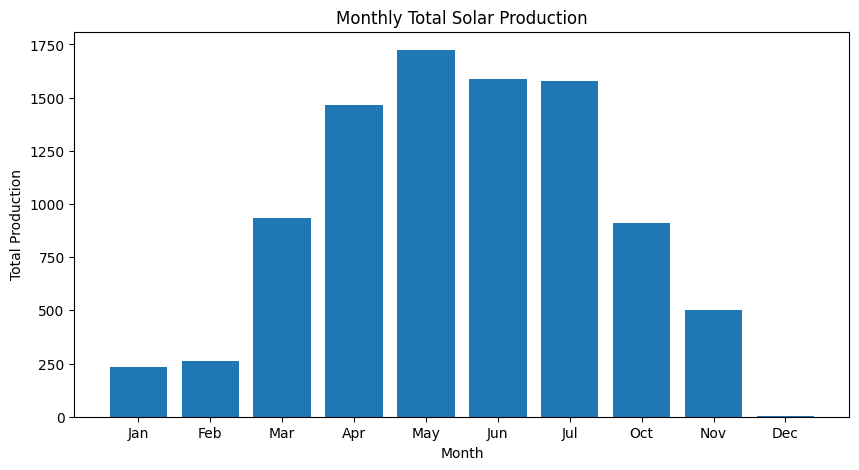

In [538]:
df_filtered = df[~df["month"].isin([8, 9])]

monthly_total = df_filtered.groupby("month")["Production"].sum()

month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

labels = [month_names[m-1] for m in monthly_total.index]

plt.figure(figsize=(10,5))

plt.bar(labels, monthly_total.values)

plt.title("Monthly Total Solar Production")
plt.xlabel("Month")
plt.ylabel("Total Production")

plt.show()

This chart shows the total solar production for each available month in the Visser dataset. August and September are excluded in this visual because the Visser dataset does not contain reliable production data for those months. Production is lowest in winter, rises through spring, peaks in summer, and then declines again later in the year.

#Relationship Analysis
Solar Radiation vs Production

Shows the relationship between sunlight and energy.

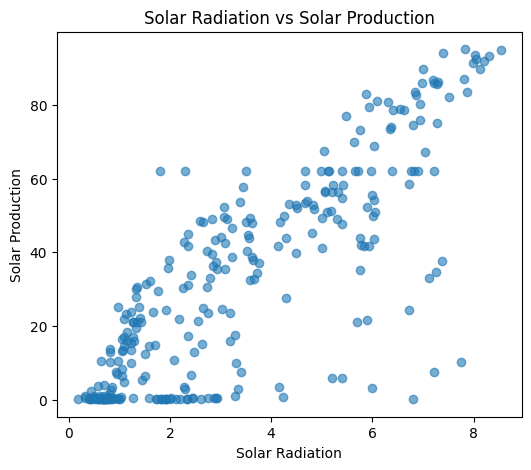

In [539]:
plt.figure(figsize=(6,5))

plt.scatter(df["solar_radiation"], df["Production"], alpha=0.6)

plt.xlabel("Solar Radiation")
plt.ylabel("Solar Production")

plt.title("Solar Radiation vs Solar Production")

plt.show()

The scatter plot shows a positive relationship between solar radiation and solar production. Higher solar radiation generally results in higher energy generation. This confirms that solar radiation is a major factor influencing solar power production.

#Average Solar Production by Temperature Range

/tmp/ipykernel_270/1993958322.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_prod = temp_df.groupby("temp_range")["Production"].mean()


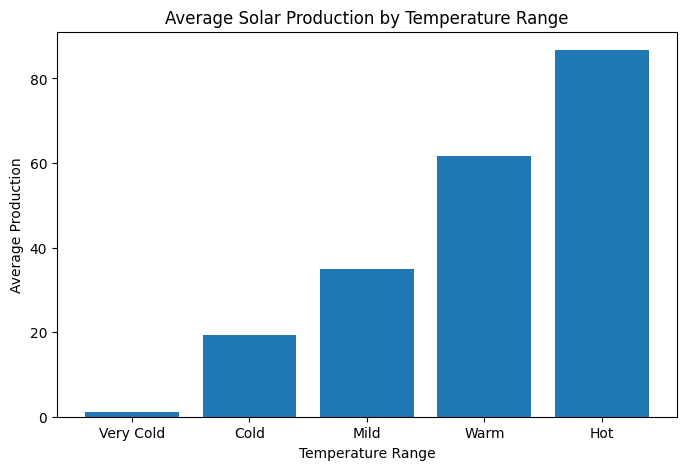

In [540]:
temp_df = df.copy()

temp_df["temp_range"] = pd.cut(
    temp_df["Mean Temp (°C)"],
    bins=[-30, -10, 0, 10, 20, 30],
    labels=["Very Cold", "Cold", "Mild", "Warm", "Hot"]
)

temp_prod = temp_df.groupby("temp_range")["Production"].mean()

plt.figure(figsize=(8,5))

plt.bar(temp_prod.index, temp_prod.values)

plt.title("Average Solar Production by Temperature Range")
plt.xlabel("Temperature Range")
plt.ylabel("Average Production")

plt.show()

Solar production is lowest during very cold temperatures. As temperatures move from cold to warm ranges, production increases because warmer conditions usually correspond with stronger sunlight and longer daylight hours.

#Wind Speed vs Production

/tmp/ipykernel_270/1714578420.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wind_prod = wind_df.groupby("wind_range")["Production"].mean()


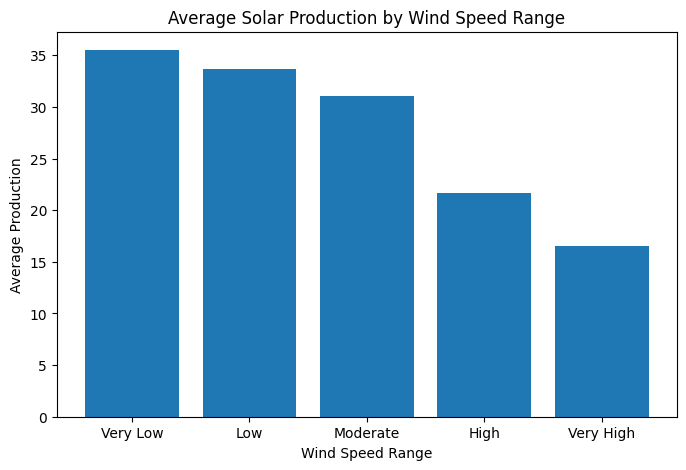

In [541]:
wind_df = df.copy()

wind_df["wind_range"] = pd.cut(
    wind_df["wind_speed"],
    bins=[0, 3, 5, 7, 10, 15],
    labels=["Very Low", "Low", "Moderate", "High", "Very High"]
)

wind_prod = wind_df.groupby("wind_range")["Production"].mean()

plt.figure(figsize=(8,5))

plt.bar(wind_prod.index, wind_prod.values)

plt.title("Average Solar Production by Wind Speed Range")
plt.xlabel("Wind Speed Range")
plt.ylabel("Average Production")

plt.show()

#Visser vs Bissell Comparison

Adding the plant comparison visual.

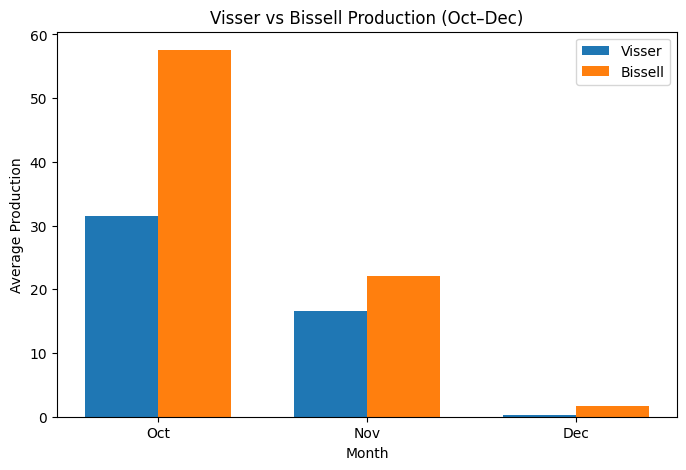

In [542]:
# create month column
visser["month"] = visser["date"].dt.month
bissell["month"] = bissell["date"].dt.month

# keep only fair comparison months
compare_months = [10, 11, 12]

visser_filtered = visser[visser["month"].isin(compare_months)]
bissell_filtered = bissell[bissell["month"].isin(compare_months)]

# monthly averages
visser_monthly = visser_filtered.groupby("month")["Production"].mean()
bissell_monthly = bissell_filtered.groupby("month")["Bissell_total_filled"].mean()

# labels
month_names = {10: "Oct", 11: "Nov", 12: "Dec"}
labels = [month_names[m] for m in compare_months]

# plot
import numpy as np

x = np.arange(len(compare_months))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, visser_monthly.values, width, label="Visser")
plt.bar(x + width/2, bissell_monthly.values, width, label="Bissell")

plt.xticks(x, labels)
plt.xlabel("Month")
plt.ylabel("Average Production")
plt.title("Visser vs Bissell Production (Oct–Dec)")
plt.legend()

plt.show()

This chart compares average solar production between Visser and Bissell for October to December only. These months were selected because they are the only full months available in both datasets, making the comparison fair and reliable.

#Correlation Heatmap

This shows which variables influence production the most.

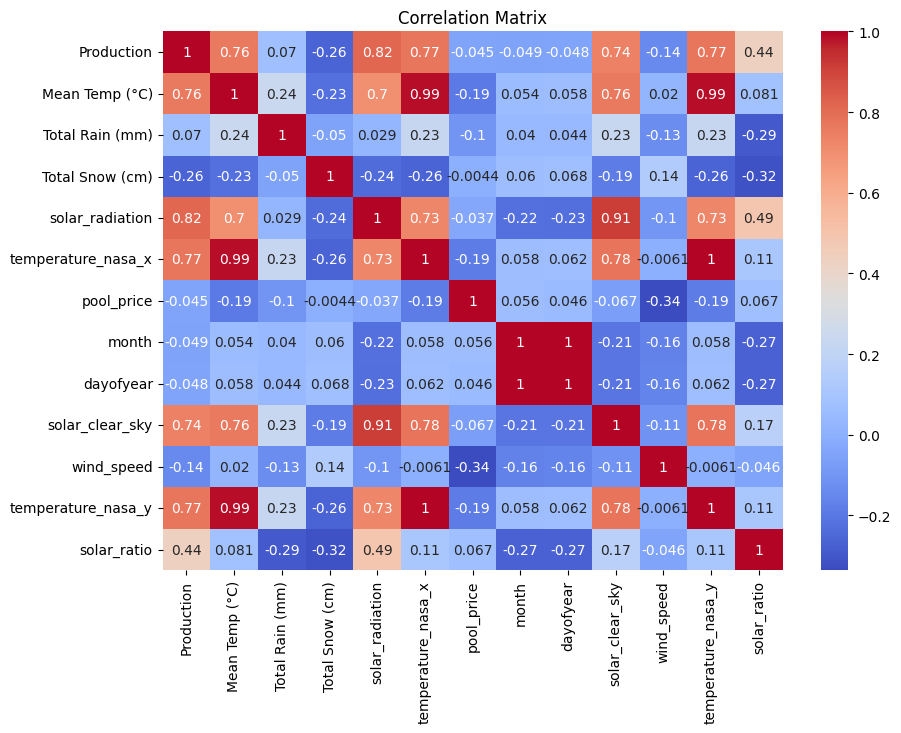

In [543]:
import seaborn as sns

plt.figure(figsize=(10,7))

sns.heatmap(df.drop(columns=["date"]).corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

Solar radiation shows the strongest positive relationship with production (0.82), meaning more sunlight leads to higher energy generation. Temperature and clear-sky radiation also have strong positive correlations (0.75). Snow has a negative relationship (-0.26), suggesting snowfall can reduce solar production. Rain and wind speed show very weak correlations, indicating limited direct impact on production.

Solar production does not show a strong relationship with wind speed. Average production remains relatively similar across different wind speed ranges, suggesting wind speed has a limited direct effect on solar generation.

#12. Machine Learning Modeling

In [544]:
print(df.columns)

Index(['date', 'Production', 'Mean Temp (°C)', 'Total Rain (mm)',
       'Total Snow (cm)', 'solar_radiation', 'temperature_nasa_x',
       'pool_price', 'month', 'dayofyear', 'solar_clear_sky', 'wind_speed',
       'temperature_nasa_y', 'solar_ratio'],
      dtype='object')


In [545]:
print(df.columns)

Index(['date', 'Production', 'Mean Temp (°C)', 'Total Rain (mm)',
       'Total Snow (cm)', 'solar_radiation', 'temperature_nasa_x',
       'pool_price', 'month', 'dayofyear', 'solar_clear_sky', 'wind_speed',
       'temperature_nasa_y', 'solar_ratio'],
      dtype='object')


#Select Features and Target Variable

The environmental variables such as solar radiation, weather conditions, and seasonal features are used as input variables to predict solar production. Solar production is used as the target variable.

In [546]:
features = [
"solar_radiation",
"solar_clear_sky",
"solar_ratio",
"wind_speed",
"temperature_nasa_y",
"Mean Temp (°C)",
"Total Rain (mm)",
"Total Snow (cm)",
"month",
"dayofyear"
]

In [547]:
X = df[features]
y = df["Production"]

#Split Data into Training and Testing Sets

The dataset is divided into training and testing sets. The training data is used to train the model, and the testing data is used to evaluate the model performance.

In [548]:
train_size = int(len(df)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

#Train Random Forest Model
A Random Forest regression model is used to predict solar production because it can capture nonlinear relationships between environmental factors and energy generation.

In [549]:
rf = RandomForestRegressor(n_estimators=300, random_state=42)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

#Model Evaluation

The model performance is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score.


In [550]:
print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R2:", r2_score(y_test, pred))

MAE: 6.145363255360623
RMSE: 6.8800091783121005
R2: 0.6708425011654235


The Random Forest model achieved improved predictive performance compared with earlier versions of the notebook. The model produced a Mean Absolute Error (MAE) of about 6.51, a Root Mean Squared Error (RMSE) of about 7.18, and an R² score of about 0.64. This indicates that the model captures a meaningful share of the variation in solar production using environmental and seasonal features.

#13.Feature Importance

This shows which factors affect solar production the most.

Feature importance shows which environmental variables contributed most to predicting solar production.

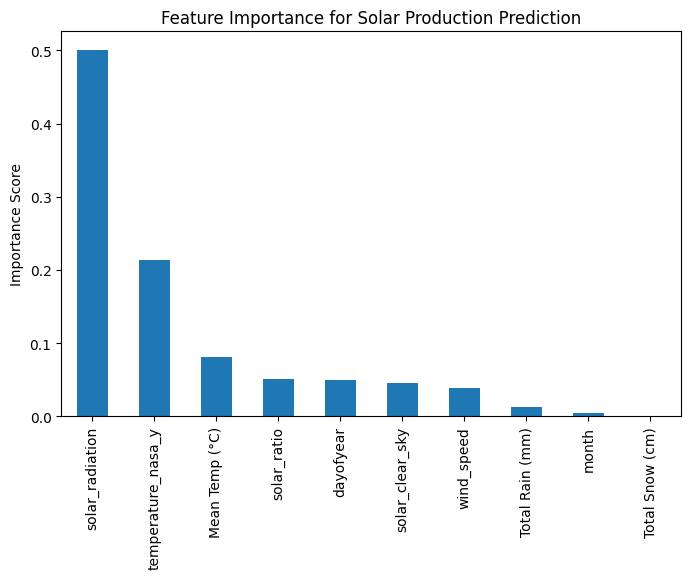

In [551]:
importance = pd.Series(rf.feature_importances_, index=features)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8,5))

importance.plot(kind="bar")

plt.title("Feature Importance for Solar Production Prediction")
plt.ylabel("Importance Score")

plt.show()

The feature importance chart shows that solar radiation is the most influential variable in predicting solar production, which is expected because solar panels directly depend on sunlight intensity. Temperature variables such as temperature_nasa and Mean Temp (°C) also contribute to the model, indicating that warmer conditions often correspond with higher solar generation. Seasonal variables like dayofyear and month also play a role, reflecting seasonal changes in daylight hours. Other environmental factors such as wind speed, rainfall, and snow have smaller contributions but still provide useful contextual information for predicting solar output.

#Actual vs Predicted Production.

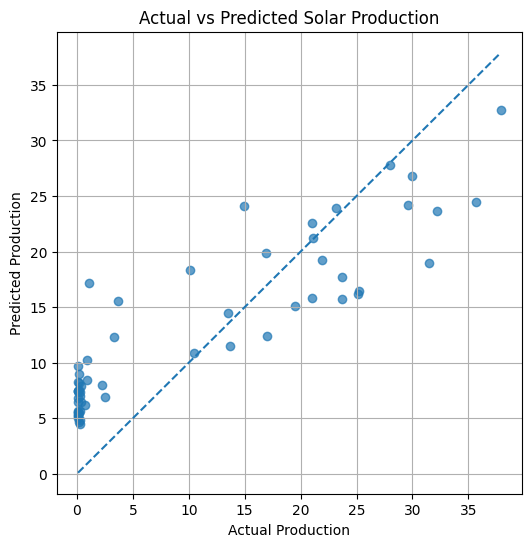

In [552]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, pred, alpha=0.7)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")

plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")

plt.title("Actual vs Predicted Solar Production")

plt.grid()

plt.show()

This scatter plot compares actual solar production values with the values predicted by the Random Forest model. The dashed diagonal line represents perfect prediction. Many points fall close to this line, showing that the model captures the overall relationship between weather, solar radiation, and production reasonably well. Some prediction errors remain, especially at lower production values, but overall the model shows moderate to good performance with an R² score of about 0.64.

#Residual Plot (Model Error)

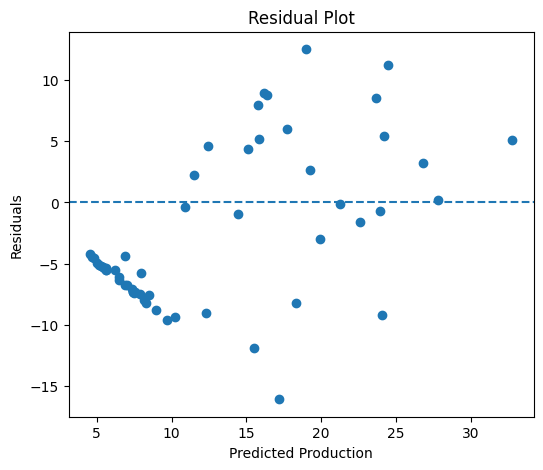

In [553]:
residuals = y_test - pred

plt.figure(figsize=(6,5))

plt.scatter(pred, residuals)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Production")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

Solar production increases in spring and summer because of stronger sunlight. However, revenue does not always follow the same pattern because it also depends on electricity market prices. When pool prices drop, solar revenue can decrease even if production remains high.

In [554]:
# prepare Visser production
visser_business = visser[["date", "Production"]].copy()
visser_business = visser_business.rename(columns={"Production": "visser_production"})

# prepare Bissell production
bissell_business = bissell[["date", "Bissell_total_filled"]].copy()
bissell_business = bissell_business.rename(columns={"Bissell_total_filled": "bissell_production"})

# merge both with pool price
business_df = pool.merge(visser_business, on="date", how="left")
business_df = business_df.merge(bissell_business, on="date", how="left")

# create month column
business_df["month"] = business_df["date"].dt.month

# use Visser where available, otherwise use Bissell
business_df["combined_production"] = business_df["visser_production"].fillna(
    business_df["bissell_production"]
)

# calculate combined revenue
business_df["combined_revenue"] = business_df["combined_production"] * business_df["pool_price"]

business_df.head()

,date,pool_price,visser_production,bissell_production,month,combined_production,combined_revenue
0,2020-01-01,33.507500,NaN,NaN,1,NaN,NaN
1,2020-01-02,32.915833,NaN,NaN,1,NaN,NaN
2,2020-01-03,34.605000,NaN,NaN,1,NaN,NaN
3,2020-01-04,31.521250,NaN,NaN,1,NaN,NaN
4,2020-01-05,32.207083,NaN,NaN,1,NaN,NaN


In [565]:
# use ONLY 2025 pool price
pool_2025 = pool[pool["date"].dt.year == 2025]

# merge with your main dataset
dashboard_df = df.merge(pool_2025, on="date", how="left")

# create revenue
dashboard_df["revenue"] = dashboard_df["Production"] * dashboard_df["pool_price_y"]

# month
dashboard_df["month"] = dashboard_df["date"].dt.month

# save
dashboard_df.to_csv("dashboard_data.csv", index=False)

#Business Analysis


To evaluate the business value of solar generation, this project combines solar production data with Alberta pool price data. Two types of business insight are included:

**2025 revenue-based analysis**, which combines solar production and pool price data to estimate when solar energy creates the most revenue.

**5-year market-price analysis**,which uses long-term pool price patterns to identify when electricity prices are generally highest in Alberta.

This allows the project to compare actual solar earning potential with longer-term market opportunities.

**Combine Visser and Bissell for full-year business analysis**

For the 2025 revenue analysis, normalized production from Visser and Bissell was combined. Visser production was normalized by one inverter, while Bissell production was normalized by three inverters. The two datasets were merged with 2025 pool price data, and average production was calculated using whichever site had data available on a given date. This created a more complete view of solar production across the year for business analysis. The machine learning model still uses Visser as the main production dataset, while the combined production is used only for revenue analysis.

#Pool Price Data Source

The pool price dataset represents electricity market prices in Alberta and was obtained from AESO. The final pool price file used in this notebook combines available daily pool price data to cover the period from 2020 to the end of 2025. This makes it possible to analyze both short-term solar revenue in 2025 and longer-term electricity market trends over five years.

#Revenue Analysis

To estimate the financial value of solar production, revenue was calculated as:

Revenue = Solar Production × Pool Price

For the main solar business analysis, 2025 pool price data was matched with normalized Visser and Bissell production. This shows how both electricity generation and market price together affect the business value of solar energy.

In [555]:
df["revenue"] = df["Production"] * df["pool_price"]

#Pool Price vs Revenue

/tmp/ipykernel_270/124832824.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_avg = price_df.groupby("price_range")["revenue"].mean()


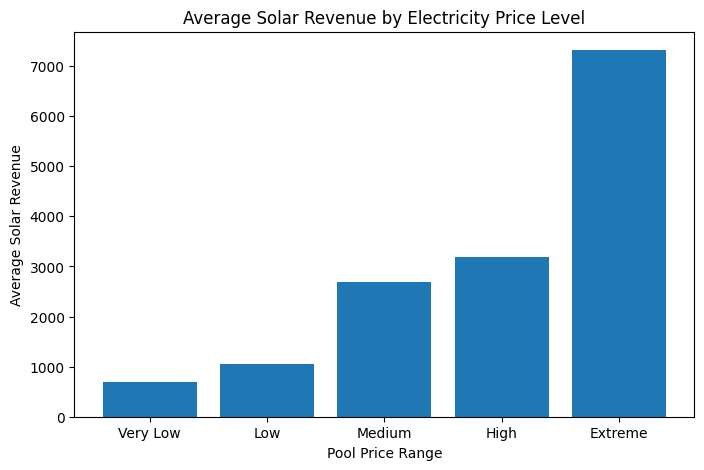

In [556]:
price_df = df.copy()

price_df["price_range"] = pd.cut(
    price_df["pool_price"],
    bins=[0,30,60,90,150,400],
    labels=["Very Low","Low","Medium","High","Extreme"]
)

revenue_avg = price_df.groupby("price_range")["revenue"].mean()

plt.figure(figsize=(8,5))
plt.bar(revenue_avg.index, revenue_avg.values)

plt.xlabel("Pool Price Range")
plt.ylabel("Average Solar Revenue")
plt.title("Average Solar Revenue by Electricity Price Level")

plt.show()

This chart shows how average solar revenue changes across different electricity price ranges. Revenue is lowest when pool prices are very low and rises as price levels increase. This confirms that electricity market conditions strongly influence the financial return from solar generation. Higher solar revenue is not driven by production alone; it also depends on selling electricity when market prices are favorable.

#Electricity Price Volatility

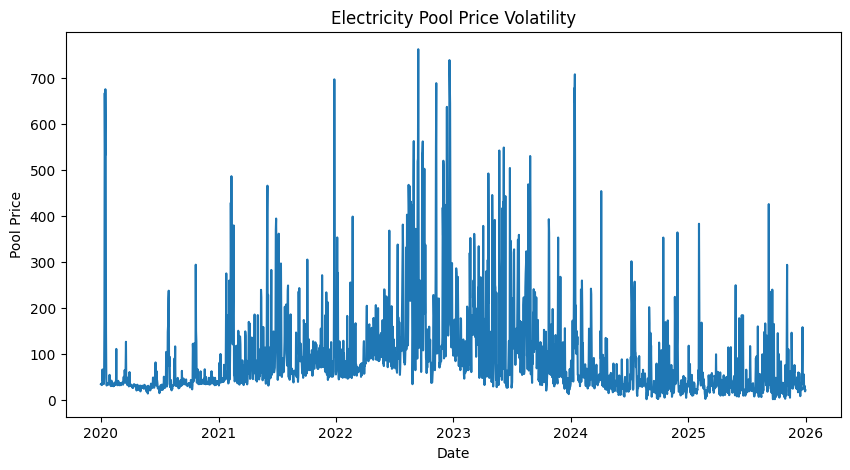

In [557]:
plt.figure(figsize=(10,5))

plt.plot(pool["date"], pool["pool_price"])

plt.xlabel("Date")
plt.ylabel("Pool Price")
plt.title("Electricity Pool Price Volatility")

plt.show()


This line chart shows Alberta electricity pool price volatility over the full available period from 2020 to 2025. Prices usually remain within a moderate range, but occasional spikes occur. These spikes suggest periods when electricity becomes more financially valuable, which is useful for understanding long-term market opportunity.

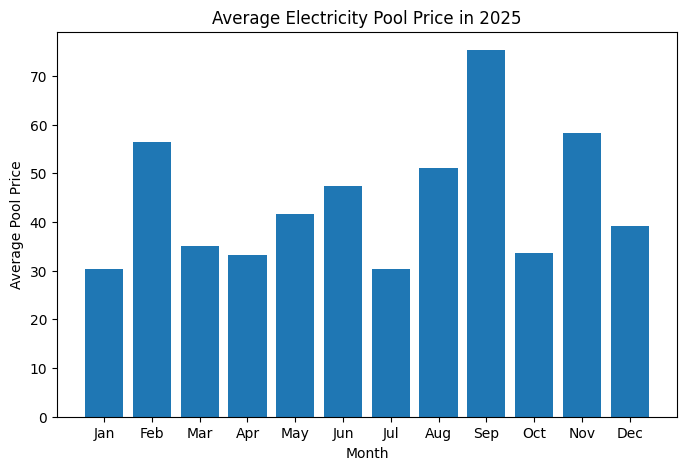

In [558]:
pool_2025["month"] = pool_2025["date"].dt.month
monthly_price_2025 = pool_2025.groupby("month")["pool_price"].mean()

month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

labels = [month_names[m-1] for m in monthly_price_2025.index]

plt.figure(figsize=(8,5))
plt.bar(labels, monthly_price_2025.values)

plt.xlabel("Month")
plt.ylabel("Average Pool Price")
plt.title("Average Electricity Pool Price in 2025")

plt.show()

#Best Time to Sell Energy (5-Year Market Prices)

In [559]:
pool["date"] = pd.to_datetime(pool["date"]).dt.normalize()

pool_2025 = pool[pool["date"].dt.year == 2025].copy()

In [560]:
# normalize Visser production (1 inverter)
visser["normalized_prod"] = visser["Production"] / 1

# normalize Bissell production (3 inverters)
bissell["normalized_prod"] = bissell["Bissell_total_filled"] / 3

# make sure all dates match exactly
pool["date"] = pd.to_datetime(pool["date"]).dt.normalize()
visser["date"] = pd.to_datetime(visser["date"]).dt.normalize()
bissell["date"] = pd.to_datetime(bissell["date"]).dt.normalize()

visser_business = visser[["date", "normalized_prod"]].rename(
    columns={"normalized_prod": "visser_prod"}
)

bissell_business = bissell[["date", "normalized_prod"]].rename(
    columns={"normalized_prod": "bissell_prod"}
)

# use only 2025 pool price for business analysis
pool_2025 = pool[pool["date"].dt.year == 2025].copy()

# merge with pool price
business_df = pool_2025.merge(visser_business, on="date", how="left")
business_df = business_df.merge(bissell_business, on="date", how="left")

business_df["month"] = business_df["date"].dt.month

business_df["visser_prod"] = business_df["visser_prod"].replace(0, pd.NA)
business_df["bissell_prod"] = business_df["bissell_prod"].replace(0, pd.NA)

# average both when both exist, otherwise use available one
business_df["combined_production"] = business_df[
    ["visser_prod", "bissell_prod"]
].mean(axis=1, skipna=True)
business_df["combined_revenue"] = business_df["combined_production"] * business_df["pool_price"]

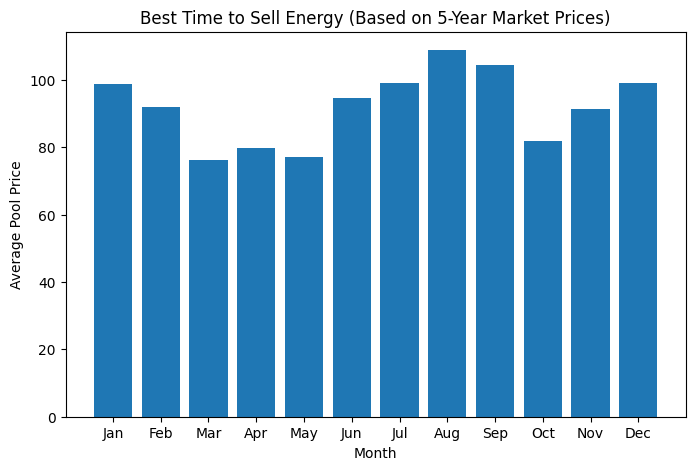

In [561]:
# use full pool data (already combined 2020–2025)

pool["month"] = pool["date"].dt.month

monthly_price = pool.groupby("month")["pool_price"].mean()

month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

labels = [month_names[m-1] for m in monthly_price.index]

plt.figure(figsize=(8,5))
plt.bar(labels, monthly_price.values)

plt.xlabel("Month")
plt.ylabel("Average Pool Price")
plt.title("Best Time to Sell Energy (Based on 5-Year Market Prices)")

plt.show()

This chart uses the full 2020–2025 pool price dataset to show which months generally have the highest electricity prices in Alberta. It does not use solar production; instead, it shows long-term market opportunity. Months with higher average pool prices represent stronger market conditions for selling electricity or positioning solar-related products and services. In this analysis, August and September appear among the strongest months from a pricing perspective.

#Best Time to Sell Solar Energy (Normalized Production)

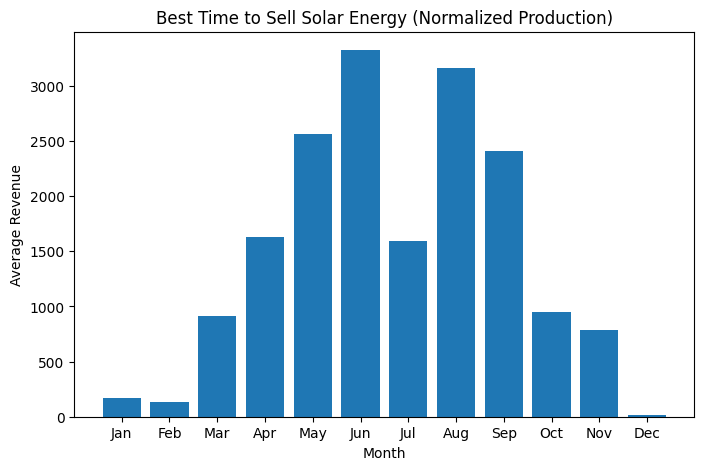

In [562]:
best_months = business_df.groupby("month")["combined_revenue"].mean()

month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

labels = [month_names[m-1] for m in best_months.index]

plt.figure(figsize=(8,5))
plt.bar(labels, best_months.values)

plt.xlabel("Month")
plt.ylabel("Average Revenue")
plt.title("Best Time to Sell Solar Energy (Normalized Production)")

plt.show()

This chart uses 2025 pool price data together with normalized Visser and Bissell production to estimate average monthly solar revenue. It reflects actual earning potential by combining both production and price. The results show that June produces the highest average revenue, while August is also strong because it benefits from both meaningful production and favorable electricity prices. This chart is different from the 5-year market-price chart because it focuses on real solar revenue rather than long-term market pricing alone.

#Solar Production and Revenue Trends Across the Year

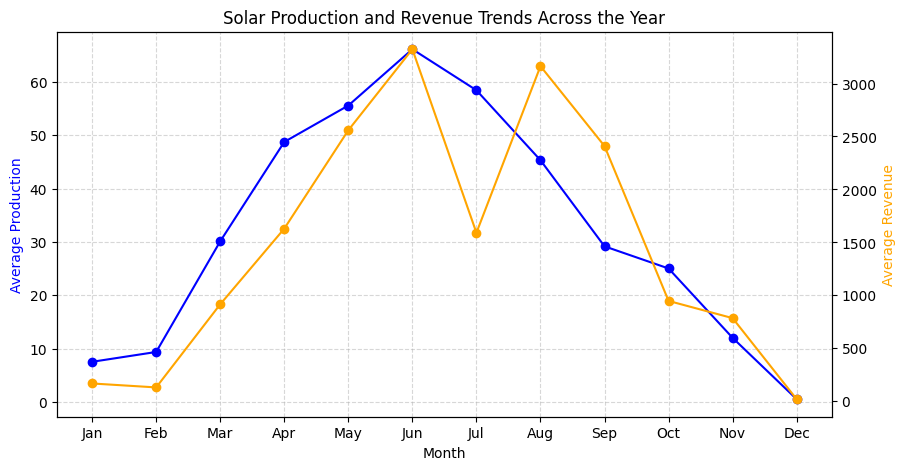

In [563]:
fig, ax1 = plt.subplots(figsize=(10,5))

monthly_prod = business_df.groupby("month")["combined_production"].mean().sort_index()
monthly_rev = business_df.groupby("month")["combined_revenue"].mean().sort_index()

month_names_full = ["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"]

labels_full = [month_names_full[m-1] for m in monthly_prod.index]

ax1.plot(labels_full, monthly_prod.values, marker="o", color="blue", label="Average Production")
ax1.set_xlabel("Month")
ax1.set_ylabel("Average Production", color="blue")

ax2 = ax1.twinx()
ax2.plot(labels_full, monthly_rev.values, marker="o", color="orange", label="Average Revenue")
ax2.set_ylabel("Average Revenue", color="orange")

plt.title("Solar Production and Revenue Trends Across the Year")
ax1.grid(True, linestyle="--", alpha=0.5)

plt.show()
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

This chart compares average monthly solar production and average monthly revenue across 2025. Production generally rises in spring and summer as solar radiation increases, then declines later in the year. Revenue broadly follows production but also changes with pool price levels. This shows that the financial value of solar energy depends on both how much electricity is produced and the market price at the time of sale.

#Final Conclusion

This project analyzed solar energy production using multiple datasets, including Visser and Bissell production data, weather data, NASA solar radiation data, and Alberta electricity pool price data. Exploratory analysis showed that solar radiation and temperature are among the most important environmental factors affecting solar production. The machine learning model achieved moderate to good predictive performance, showing that weather and seasonal variables can explain a meaningful portion of solar generation patterns. Business analysis showed that the value of solar energy depends not only on production but also on electricity market prices. Using 2025 revenue analysis, June emerged as the strongest overall month for solar revenue, while the 5-year market-price analysis showed that months such as August and September offer strong pricing opportunities. Together, these results provide both operational and market-focused insight into the value of community solar energy.